In [5]:
# Célula 1: Setup e Carregamento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Carrega .env
load_dotenv(dotenv_path=Path("../.env"))

# Configs visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Caminhos
PROC = Path("../data/processed")

# Conexão
DB_USER = "postgres"
DB_PASS = quote_plus(os.environ.get("DB_PASS", ""))
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "pecuaria"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Carrega estoque e preços CEPEA
df_estoque = pd.read_sql("SELECT * FROM estoque", con=engine)
df_milho   = pd.read_csv(PROC / "cepea_milho.csv",    parse_dates=['data'])
df_soja    = pd.read_csv(PROC / "cepea_soja.csv",     parse_dates=['data'])
df_boi     = pd.read_csv(PROC / "cepea_boigordo.csv", parse_dates=['data'])

print(f"Dados carregados!")
print(f"   Estoque:    {len(df_estoque)} registros")
print(f"   Milho CEPEA: {len(df_milho)} registros")
print(f"   Soja CEPEA:  {len(df_soja)} registros")
print(f"   Boi CEPEA:   {len(df_boi)} registros")
print(f"\nColunas estoque: {df_estoque.columns.tolist()}")

Dados carregados!
   Estoque:    540 registros
   Milho CEPEA: 1558 registros
   Soja CEPEA:  1558 registros
   Boi CEPEA:   1557 registros

Colunas estoque: ['id_estoque', 'lote', 'n_animais', 'data_ref', 'insumo', 'consumo_kg', 'preco_rs_kg', 'custo_total_rs', 'estoque_kg']


In [6]:
# Célula 2: Preparando séries temporais pro Prophet
print("--- PREPARANDO SÉRIES PARA O PROPHET ---")

# ── Série 1: Preço do Milho (dado real CEPEA) ─────────────────────────────
df_milho_prophet = df_milho[['data', 'preco_rs']].rename(
    columns={'data': 'ds', 'preco_rs': 'y'}
).copy()

# ── Série 2: Preço da Soja (dado real CEPEA) ──────────────────────────────
df_soja_prophet = df_soja[['data', 'preco_rs']].rename(
    columns={'data': 'ds', 'preco_rs': 'y'}
).copy()

# ── Série 3: Preço do Boi Gordo (dado real CEPEA) ─────────────────────────
df_boi_prophet = df_boi[['data', 'preco_rs']].rename(
    columns={'data': 'ds', 'preco_rs': 'y'}
).copy()

# ── Série 4: Consumo mensal de milho (dado simulado agregado) ─────────────
df_consumo_milho = (
    df_estoque[df_estoque['insumo'] == 'milho']
    .groupby('data_ref')['consumo_kg']
    .sum()
    .reset_index()
    .rename(columns={'data_ref': 'ds', 'consumo_kg': 'y'})
)
df_consumo_milho['ds'] = pd.to_datetime(df_consumo_milho['ds'])

# Diagnóstico
for nome, df in [
    ("Milho CEPEA",     df_milho_prophet),
    ("Soja CEPEA",      df_soja_prophet),
    ("Boi Gordo CEPEA", df_boi_prophet),
    ("Consumo Milho",   df_consumo_milho),
]:
    print(f"\n{nome}")
    print(f"   Período: {df['ds'].min().date()} → {df['ds'].max().date()}")
    print(f"   Registros: {len(df)}")
    print(f"   y — mín: {df['y'].min():.2f} | máx: {df['y'].max():.2f}")

--- PREPARANDO SÉRIES PARA O PROPHET ---

Milho CEPEA
   Período: 2020-01-02 → 2026-03-31
   Registros: 1558
   y — mín: 46.81 | máx: 103.90

Soja CEPEA
   Período: 2020-01-02 → 2026-03-31
   Registros: 1558
   y — mín: 84.73 | máx: 207.14

Boi Gordo CEPEA
   Período: 2020-01-02 → 2026-03-31
   Registros: 1557
   y — mín: 186.10 | máx: 356.00

Consumo Milho
   Período: 2024-07-01 → 2025-12-01
   Registros: 18
   y — mín: 67500.00 | máx: 67500.00


In [7]:
# Célula 3: Treinando o Prophet para Milho, Soja e Boi Gordo
print("--- TREINANDO MODELOS PROPHET ---")

modelos = {}
previsoes = {}
DIAS_FUTURO = 90  # previsão pra 90 dias

for nome, df_serie in [
    ("milho",     df_milho_prophet),
    ("soja",      df_soja_prophet),
    ("boi_gordo", df_boi_prophet),
]:
    print(f"\n🔄 Treinando Prophet para {nome}...")

    modelo = Prophet(
        yearly_seasonality=True,   # captura ciclos anuais
        weekly_seasonality=True,   # captura variação semanal
        daily_seasonality=False,   # não precisa pra preço
        changepoint_prior_scale=0.05  # sensibilidade a mudanças de tendência
    )

    modelo.fit(df_serie)

    # Cria calendário futuro
    futuro = modelo.make_future_dataframe(periods=DIAS_FUTURO)

    # Faz previsão
    previsao = modelo.predict(futuro)

    modelos[nome]   = modelo
    previsoes[nome] = previsao

    # Mostra resumo da previsão
    prox_90 = previsao[previsao['ds'] > df_serie['ds'].max()]
    print(f"      {nome} — previsão próximos 90 dias:")
    print(f"      Mín: R$ {prox_90['yhat'].min():.2f}")
    print(f"      Máx: R$ {prox_90['yhat'].max():.2f}")
    print(f"      Média: R$ {prox_90['yhat'].mean():.2f}")

print("\nTodos os modelos treinados!")

--- TREINANDO MODELOS PROPHET ---

🔄 Treinando Prophet para milho...


01:30:07 - cmdstanpy - INFO - Chain [1] start processing
01:30:16 - cmdstanpy - INFO - Chain [1] done processing


      milho — previsão próximos 90 dias:
      Mín: R$ 54.81
      Máx: R$ 72.33
      Média: R$ 62.41

🔄 Treinando Prophet para soja...


01:30:18 - cmdstanpy - INFO - Chain [1] start processing
01:30:20 - cmdstanpy - INFO - Chain [1] done processing


      soja — previsão próximos 90 dias:
      Mín: R$ 127.42
      Máx: R$ 133.58
      Média: R$ 130.30

🔄 Treinando Prophet para boi_gordo...


01:30:21 - cmdstanpy - INFO - Chain [1] start processing
01:30:22 - cmdstanpy - INFO - Chain [1] done processing


      boi_gordo — previsão próximos 90 dias:
      Mín: R$ 315.49
      Máx: R$ 348.14
      Média: R$ 328.44

Todos os modelos treinados!


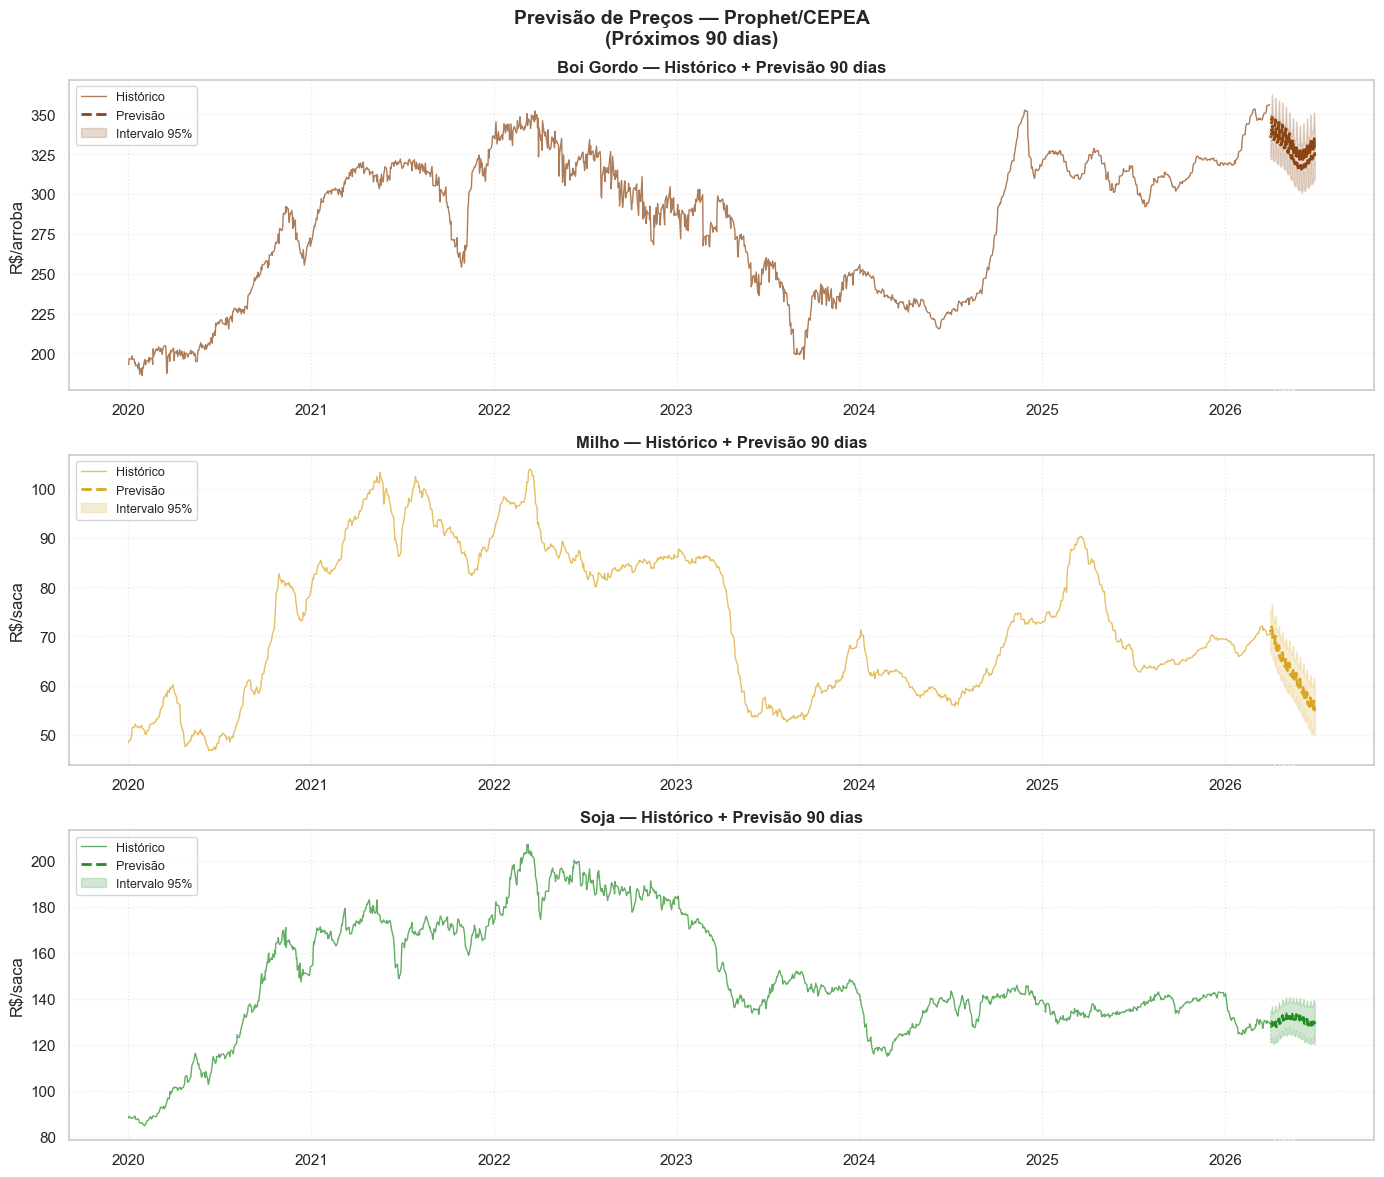

Gráfico salvo!


In [8]:
# Célula 4: Gráficos de Previsão Prophet
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

configs = [
    ("boi_gordo", "Boi Gordo", "R$/arroba", "#8B4513"),
    ("milho",     "Milho",     "R$/saca",   "#DAA520"),
    ("soja",      "Soja",      "R$/saca",   "#228B22"),
]

for ax, (chave, nome, unidade, cor) in zip(axes, configs):
    df_hist = modelos[chave].history
    df_prev = previsoes[chave]
    data_corte = df_hist['ds'].max()

    # Histórico
    ax.plot(df_hist['ds'], df_hist['y'],
            color=cor, linewidth=1.0, alpha=0.7, label='Histórico')

    # Previsão
    df_futuro = df_prev[df_prev['ds'] > data_corte]
    ax.plot(df_futuro['ds'], df_futuro['yhat'],
            color=cor, linewidth=2.0, linestyle='--', label='Previsão')

    # Intervalo de confiança
    ax.fill_between(
        df_futuro['ds'],
        df_futuro['yhat_lower'],
        df_futuro['yhat_upper'],
        alpha=0.2, color=cor, label='Intervalo 95%'
    )

    # Linha de corte
    ax.axvline(data_corte, color='white', linewidth=1.0,
               linestyle=':', alpha=0.7)
    ax.text(data_corte, ax.get_ylim()[0],
            ' Hoje', fontsize=8, color='white', alpha=0.7)

    ax.set_title(f'{nome} — Histórico + Previsão 90 dias',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel(unidade)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.suptitle('Previsão de Preços — Prophet/CEPEA\n(Próximos 90 dias)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC / 'grafico_prophet_previsao.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico salvo!")

In [9]:
# Célula 5: Janela de Compra Recomendada
print("--- IDENTIFICANDO JANELA DE COMPRA ---")

CONSUMO_DIARIO_MILHO = 4.5 * 500   # kg/dia — 500 animais
CONSUMO_DIARIO_SOJA  = 1.2 * 500   # kg/dia

resultados_compra = []

for chave, consumo_diario, unidade in [
    ("milho", CONSUMO_DIARIO_MILHO, "saca 60kg"),
    ("soja",  CONSUMO_DIARIO_SOJA,  "saca 60kg"),
]:
    df_prev = previsoes[chave]
    data_corte = modelos[chave].history['ds'].max()
    df_futuro = df_prev[df_prev['ds'] > data_corte].copy()

    # Converte preço saca → R$/kg
    df_futuro['preco_kg'] = df_futuro['yhat'] / 60

    # Custo diário projetado
    df_futuro['custo_diario'] = df_futuro['preco_kg'] * consumo_diario

    # Custo acumulado 90 dias
    custo_total_90d = df_futuro['custo_diario'].sum()

    # Identifica dia mais barato (melhor janela de compra)
    idx_min = df_futuro['yhat'].idxmin()
    dia_compra = df_futuro.loc[idx_min, 'ds']
    preco_min  = df_futuro.loc[idx_min, 'yhat']

    # Identifica dia mais caro
    idx_max = df_futuro['yhat'].idxmax()
    dia_caro  = df_futuro.loc[idx_max, 'ds']
    preco_max = df_futuro.loc[idx_max, 'yhat']

    # Economia potencial comprando no mínimo vs máximo
    consumo_90d_kg = consumo_diario * 90
    economia = (preco_max - preco_min) / 60 * consumo_90d_kg

    resultados_compra.append({
        'insumo':       chave,
        'dia_compra':   dia_compra.date(),
        'preco_min_rs': round(preco_min, 2),
        'dia_caro':     dia_caro.date(),
        'preco_max_rs': round(preco_max, 2),
        'custo_90d_rs': round(custo_total_90d, 2),
        'economia_rs':  round(economia, 2),
    })

    print(f"\n{'='*45}")
    print(f"{chave.upper()}")
    print(f"Melhor dia pra comprar: {dia_compra.date()}")
    print(f"Preço previsto: R$ {preco_min:.2f}/{unidade}")
    print(f"Pior dia (mais caro): {dia_caro.date()}")
    print(f"Preço previsto: R$ {preco_max:.2f}/{unidade}")
    print(f"Economia potencial: R$ {economia:,.2f}")
    print(f"Custo total 90 dias: R$ {custo_total_90d:,.2f}")

df_compra = pd.DataFrame(resultados_compra)
df_compra.to_csv(PROC / 'janela_compra_recomendada.csv', index=False)
print(f"\nJanela de compra salva!")
print(df_compra)

--- IDENTIFICANDO JANELA DE COMPRA ---

MILHO
Melhor dia pra comprar: 2026-06-29
Preço previsto: R$ 54.81/saca 60kg
Pior dia (mais caro): 2026-04-04
Preço previsto: R$ 72.33/saca 60kg
Economia potencial: R$ 59,138.07
Custo total 90 dias: R$ 210,633.71

SOJA
Melhor dia pra comprar: 2026-04-07
Preço previsto: R$ 127.42/saca 60kg
Pior dia (mais caro): 2026-05-09
Preço previsto: R$ 133.58/saca 60kg
Economia potencial: R$ 5,540.56
Custo total 90 dias: R$ 117,269.35

Janela de compra salva!
  insumo  dia_compra  preco_min_rs    dia_caro  preco_max_rs  custo_90d_rs  \
0  milho  2026-06-29         54.81  2026-04-04         72.33     210633.71   
1   soja  2026-04-07        127.42  2026-05-09        133.58     117269.35   

   economia_rs  
0     59138.07  
1      5540.56  


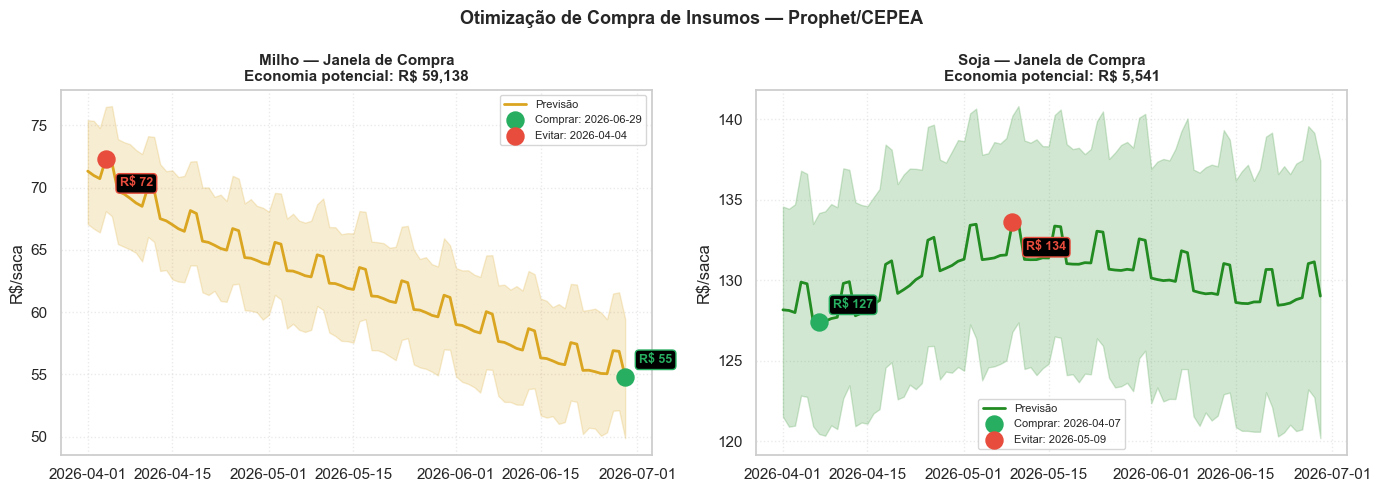

Gráfico da janela de compra salvo!


In [10]:
# Célula 6: Gráfico da Janela de Compra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    ("milho", "Milho", "#DAA520"),
    ("soja",  "Soja",  "#228B22"),
]

for ax, (chave, nome, cor) in zip(axes, configs):
    data_corte = modelos[chave].history['ds'].max()
    df_futuro  = previsoes[chave][previsoes[chave]['ds'] > data_corte].copy()

    ax.plot(df_futuro['ds'], df_futuro['yhat'],
            color=cor, linewidth=2.0, label='Previsão')
    ax.fill_between(df_futuro['ds'],
                    df_futuro['yhat_lower'],
                    df_futuro['yhat_upper'],
                    alpha=0.2, color=cor)

    # Marca melhor dia
    row = df_compra[df_compra['insumo'] == chave].iloc[0]
    dia_min   = pd.Timestamp(row['dia_compra'])
    preco_min = row['preco_min_rs']
    dia_max   = pd.Timestamp(row['dia_caro'])
    preco_max = row['preco_max_rs']

    ax.scatter([dia_min], [preco_min], color='#27AE60',
               s=150, zorder=5, label=f'Comprar: {dia_min.date()}')
    ax.scatter([dia_max], [preco_max], color='#E74C3C',
               s=150, zorder=5, label=f'Evitar: {dia_max.date()}')

    ax.annotate(f'R$ {preco_min:.0f}',
                xy=(dia_min, preco_min),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color='#27AE60', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='black', edgecolor='#27AE60'))

    ax.annotate(f'R$ {preco_max:.0f}',
                xy=(dia_max, preco_max),
                xytext=(10, -20), textcoords='offset points',
                fontsize=9, color='#E74C3C', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='black', edgecolor='#E74C3C'))

    economia = row['economia_rs']
    ax.set_title(f'{nome} — Janela de Compra\nEconomia potencial: R$ {economia:,.0f}',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('R$/saca')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.suptitle('Otimização de Compra de Insumos — Prophet/CEPEA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROC / 'grafico_janela_compra.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico da janela de compra salvo!")

In [11]:
# Célula 7: Criando Views no PostgreSQL para o Power BI
print("--- CRIANDO VIEWS ANALÍTICAS ---")

views = {

"vw_resumo_rebanho": """
CREATE OR REPLACE VIEW vw_resumo_rebanho AS
SELECT
    COUNT(*)                          AS total_animais,
    ROUND(AVG(peso_kg)::numeric, 1)   AS peso_medio_kg,
    ROUND(AVG(arroba_atual)::numeric, 2) AS arroba_media,
    ROUND(AVG(gmd_total)::numeric, 3) AS gmd_medio,
    ROUND(SUM(valor_mercado_rs)::numeric, 2) AS valor_total_rebanho,
    ROUND(AVG(valor_mercado_rs)::numeric, 2) AS valor_medio_animal,
    ROUND(AVG(margem_bruta_rs)::numeric, 2)  AS margem_media,
    ROUND(SUM(margem_bruta_rs)::numeric, 2)  AS margem_total
FROM performance;
""",

"vw_performance_por_raca": """
CREATE OR REPLACE VIEW vw_performance_por_raca AS
SELECT
    raca,
    COUNT(*)                              AS total_animais,
    ROUND(AVG(gmd_total)::numeric, 3)     AS gmd_medio,
    ROUND(AVG(conversao_alimentar)::numeric, 2) AS ca_media,
    ROUND(AVG(margem_bruta_rs)::numeric, 2)     AS margem_media,
    ROUND(AVG(valor_mercado_rs)::numeric, 2)    AS valor_medio,
    ROUND(AVG(custo_por_kg_ganho)::numeric, 2)  AS custo_kg_medio
FROM performance
GROUP BY raca
ORDER BY gmd_medio DESC;
""",

"vw_performance_por_cluster": """
CREATE OR REPLACE VIEW vw_performance_por_cluster AS
SELECT
    c.cluster_nome,
    COUNT(*)                              AS total_animais,
    ROUND(AVG(p.gmd_total)::numeric, 3)   AS gmd_medio,
    ROUND(AVG(p.conversao_alimentar)::numeric, 2) AS ca_media,
    ROUND(AVG(p.margem_bruta_rs)::numeric, 2)     AS margem_media,
    ROUND(AVG(p.custo_por_kg_ganho)::numeric, 2)  AS custo_kg_medio,
    ROUND(AVG(p.dias_conf)::numeric, 1)           AS dias_conf_medio,
    ROUND(SUM(p.valor_mercado_rs)::numeric, 2)    AS valor_total
FROM performance p
JOIN clusters_rebanho c ON p.id_animal = c.id_animal
GROUP BY c.cluster_nome
ORDER BY gmd_medio DESC;
""",

"vw_evolucao_peso_mensal": """
CREATE OR REPLACE VIEW vw_evolucao_peso_mensal AS
SELECT
    DATE_TRUNC('month', data_pesagem)     AS mes,
    ROUND(AVG(peso_kg)::numeric, 1)       AS peso_medio,
    ROUND(AVG(arroba_atual)::numeric, 2)  AS arroba_media,
    ROUND(AVG(gmd_periodo)::numeric, 3)   AS gmd_medio,
    ROUND(SUM(valor_mercado_rs)::numeric, 2) AS valor_total,
    ROUND(AVG(preco_arroba_rs)::numeric, 2)  AS preco_arroba_medio
FROM pesagens
GROUP BY DATE_TRUNC('month', data_pesagem)
ORDER BY mes;
""",

"vw_custo_sanitario_por_tipo": """
CREATE OR REPLACE VIEW vw_custo_sanitario_por_tipo AS
SELECT
    tipo,
    produto,
    COUNT(*)                              AS total_aplicacoes,
    ROUND(SUM(custo_total)::numeric, 2)   AS custo_total_rs,
    ROUND(AVG(custo_total)::numeric, 2)   AS custo_medio_rs
FROM sanitario
GROUP BY tipo, produto
ORDER BY custo_total_rs DESC;
""",

"vw_estoque_atual": """
CREATE OR REPLACE VIEW vw_estoque_atual AS
SELECT
    insumo,
    ROUND(SUM(consumo_kg)::numeric, 1)    AS consumo_total_kg,
    ROUND(AVG(preco_rs_kg)::numeric, 4)   AS preco_medio_kg,
    ROUND(SUM(custo_total_rs)::numeric, 2) AS custo_total_rs,
    ROUND(AVG(estoque_kg)::numeric, 1)    AS estoque_medio_kg,
    MAX(data_ref)                         AS ultima_atualizacao
FROM estoque
GROUP BY insumo
ORDER BY custo_total_rs DESC;
""",

"vw_animais_criticos": """
CREATE OR REPLACE VIEW vw_animais_criticos AS
SELECT
    p.brinco,
    p.raca,
    p.lote,
    p.gmd_total,
    p.conversao_alimentar,
    p.margem_bruta_rs,
    p.custo_por_kg_ganho,
    p.dias_conf,
    c.cluster_nome
FROM performance p
JOIN clusters_rebanho c ON p.id_animal = c.id_animal
WHERE c.cluster_nome = 'Baixa Performance'
ORDER BY p.margem_bruta_rs ASC;
"""
}

with engine.connect() as conn:
    for nome, sql in views.items():
        conn.execute(text(sql))
        conn.commit()
        print(f"View criada: {nome}")

print("\nTodas as views criadas no PostgreSQL!")

--- CRIANDO VIEWS ANALÍTICAS ---
View criada: vw_resumo_rebanho
View criada: vw_performance_por_raca
View criada: vw_performance_por_cluster
View criada: vw_evolucao_peso_mensal
View criada: vw_custo_sanitario_por_tipo
View criada: vw_estoque_atual
View criada: vw_animais_criticos

Todas as views criadas no PostgreSQL!


In [13]:
# Célula 8: Exportando Views para CSV (Power BI)
print("--- EXPORTANDO PARA POWER BI ---")

# Define caminhos
PBI  = Path("../powerbi/data")
PROC = Path("../data/processed")
PBI.mkdir(parents=True, exist_ok=True)

views_exportar = [
    "vw_resumo_rebanho",
    "vw_performance_por_raca",
    "vw_performance_por_cluster",
    "vw_evolucao_peso_mensal",
    "vw_custo_sanitario_por_tipo",
    "vw_estoque_atual",
    "vw_animais_criticos",
]

for view in views_exportar:
    df_view = pd.read_sql(f"SELECT * FROM {view}", con=engine)
    caminho = PBI / f"{view}.csv"
    df_view.to_csv(caminho, index=False, decimal=',', sep=';')
    print(f"{view}.csv reexportado")

# Tabelas principais também
tabelas = {
    "performance_com_clusters": pd.read_csv(PROC / "performance_com_clusters.csv"),
    "janela_compra":            pd.read_csv(PROC / "janela_compra_recomendada.csv"),
    "cepea_milho":              pd.read_csv(PROC / "cepea_milho.csv"),
    "cepea_soja":               pd.read_csv(PROC / "cepea_soja.csv"),
    "cepea_boigordo":           pd.read_csv(PROC / "cepea_boigordo.csv"),
}

for nome, df_exp in tabelas.items():
    df_exp.to_csv(PBI / f"{nome}.csv", index=False, decimal=',', sep=';')
    print(f"{nome}.csv — {len(df_exp)} registros")

print(f"\nTodos os arquivos exportados para powerbi/data/")
print(f"   Total de arquivos: {len(list(PBI.glob('*.csv')))}")

--- EXPORTANDO PARA POWER BI ---
vw_resumo_rebanho.csv reexportado
vw_performance_por_raca.csv reexportado
vw_performance_por_cluster.csv reexportado
vw_evolucao_peso_mensal.csv reexportado
vw_custo_sanitario_por_tipo.csv reexportado
vw_estoque_atual.csv reexportado
vw_animais_criticos.csv reexportado
performance_com_clusters.csv — 500 registros
janela_compra.csv — 2 registros
cepea_milho.csv — 1558 registros
cepea_soja.csv — 1558 registros
cepea_boigordo.csv — 1557 registros

Todos os arquivos exportados para powerbi/data/
   Total de arquivos: 12
